<a href="https://colab.research.google.com/github/sahferr/my_colab/blob/main/implementando_deep_learning_do_zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''vamos trabalhar o problema do MNIST

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt

from time import time
from torchvision import datasets, transforms
from torch import nn, optim

In [ ]:
#define a conversão de img
transform = transforms.ToTensor()

#carrega o treino do dataset
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)

#cria um buffet para pegar os dados por partes
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

#carrega parte da validação
valset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=False, transform=transform)

#criar buffet para pegar os dados
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 462kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.21MB/s]


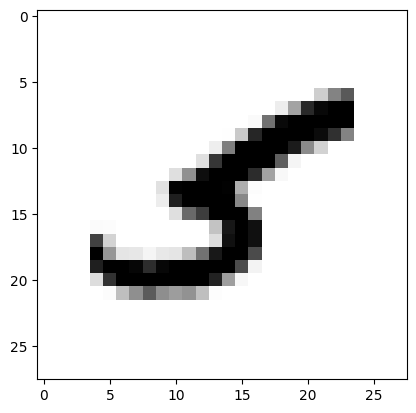

In [ ]:
dataiter = iter(trainloader)
imagens, labels = next(dataiter)

plt.imshow(imagens[0].numpy().squeeze(), cmap='gray_r')

In [ ]:
#para verificar as dimensões da img
print(f'imagens: {imagens[0].shape}')

# para verificar as dimensões de cada etiqueta
print(f'labels:{labels[0].shape}')


imagens: torch.Size([1, 28, 28])
labels:torch.Size([])


In [ ]:
class Model(nn.Module):

  def __init__(self):
    super(Model, self).__init__()

    # camada de entrada 784nn
    self.linear1 = nn.Linear(28*28,  128)
    self.linear2 = nn.Linear(128, 64)
    self.linear3 = nn.Linear(64, 10)

  def forward(self, x):
    X  = F.relu(self.linear1(x))
    X = F.relu(self.linear2(X))
    X = self.linear3(X)

    return F.log_softmax(X, dim=1)

In [ ]:
def trainer(modelo, trainloader, device):

  #define as politicas de atualização

  otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5)
  inicio = time()

  criterio = nn.NLLLoss() #para cal a perda
  EPOCHS = 10 # epochs que o alg, rodará
  modelo.train() #on-trainner

  for epoch in range(EPOCHS):
    perda_acumulada = 0

    for imagens, labels in trainloader:

      imagens = imagens.view(imagens.shape[0], -1) # converter a img em vetor
      otimizador.zero_grad() # zera os gradientes por conta do ciclo  anterior
      output = modelo(imagens.to(device)) # coloca os dados no modelo
      perda_instantanea = criterio(output, labels.to(device))

      perda_instantanea.backward() # calcula os gradientes
      otimizador.step() # atualiza os pesos
      perda_acumulada += perda_instantanea.item()

  else:
    print(f'epoch {epoch+1} - perda resultante: {perda_acumulada/len(trainloader)}')

  print(f'tempo de treino: {(time()-inicio)/60}')

In [ ]:
modelo = Model()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

trainer(modelo, trainloader, device)

epoch 10 - perda resultante: 0.14506511142187473
tempo de treino: 1.5065791289011636
